# File Handling & Exception Handling in Python — A Complete Hands-On Lab

Welcome to this hands-on lab on two of Python’s most essential skills: **File Handling** and **Exception Handling**. You will read, write, and manage real data files — and write code that never crashes on unexpected input.

---

### Learning Objectives

| # | Skill |
|---|-------|
| 1 | Read text files using `open()`, `read()`, `readline()`, `readlines()` |
| 2 | Write and append data with `"w"` and `"a"` file modes |
| 3 | Use the `with` statement (context manager) for safe, automatic file closing |
| 4 | Process **CSV** files with Python’s built-in `csv` module |
| 5 | Read and write **JSON** files using Python’s `json` module |
| 6 | Handle errors with `try / except / else / finally` |
| 7 | Define and raise **custom exceptions** for domain-specific errors |
| 8 | Build a complete real-world **Student Grade Management System** |

---

### Our Real-World Project: SmartGrade

> A school needs a system to manage student data across three file formats — attendance logs (`.txt`), grade sheets (`.csv`), and student profiles (`.json`). Every file operation must be protected against missing files, bad data, and permission errors.

*Each section adds one skill. The final project assembles them all into a working `GradeBook` class.*


---

## Architecture Overview — Two Pillars, One System

This lab covers two complementary Python capabilities that every real program needs:

- **File Handling** — persist data beyond a single run using `.txt`, `.csv`, and `.json`
- **Exception Handling** — prevent crashes and respond cleanly to errors

Together they power **SmartGrade**, the student records system we build step by step.


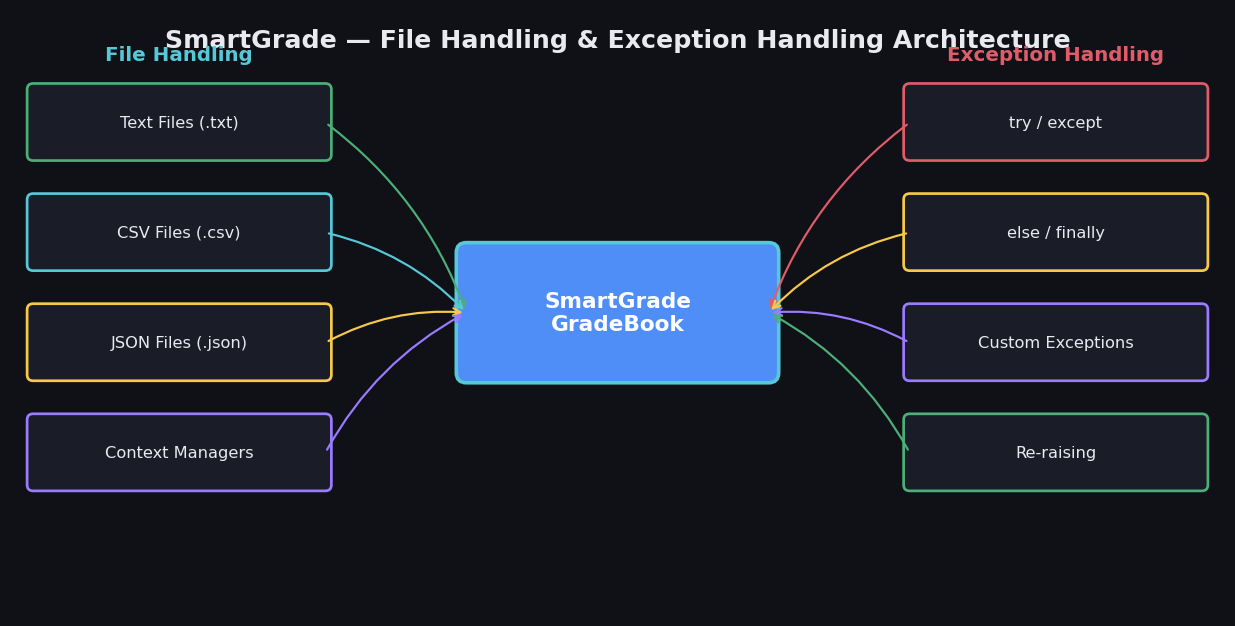


### How to Read This Diagram

| Side | Skill Area | What It Covers |
|------|-----------|----------------|
| Left | **File Handling** | Text files, CSV, JSON, Context Managers |
| Right | **Exception Handling** | try/except, else/finally, Custom Exceptions, Re-raising |
| Centre | **GradeBook** | Final project that integrates every skill |

> Each arrow shows one skill flowing into the finished system.


---

## Section 1: Setup — Creating Sample Data Files

The first code cell creates the three sample files used throughout the lab inside a `grade_records/` folder.

| File | Format | Purpose |
|------|--------|---------|
| `attendance.txt` | Plain text | Daily attendance log |
| `grades.csv` | CSV | Student mark records |
| `profiles.json` | JSON | Student profile data |


In [ ]:
import os, csv, json

# Create working directory
os.makedirs("grade_records", exist_ok=True)

# ── 1. Attendance log (plain text) ───────────────────────────────
attendance_data = (
    "2024-01-15,S001,Alice Johnson,Present\n"
    "2024-01-15,S002,Bob Smith,Absent\n"
    "2024-01-15,S003,Carol White,Present\n"
    "2024-01-15,S004,David Brown,Present\n"
    "2024-01-15,S005,Emma Davis,Late\n"
    "2024-01-16,S001,Alice Johnson,Present\n"
    "2024-01-16,S002,Bob Smith,Present\n"
    "2024-01-16,S003,Carol White,Absent\n"
    "2024-01-16,S004,David Brown,Present\n"
    "2024-01-16,S005,Emma Davis,Present"
)
with open("grade_records/attendance.txt", "w") as f:
    f.write(attendance_data)

# ── 2. Grade sheet (CSV) ──────────────────────────────────────────
with open("grade_records/grades.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["StudentID", "Name", "Math", "Science", "English", "Grade"])
    writer.writerows([
        ["S001", "Alice Johnson", 92, 88, 95, "A"],
        ["S002", "Bob Smith",     75, 80, 70, "B"],
        ["S003", "Carol White",   88, 91, 85, "A"],
        ["S004", "David Brown",   60, 65, 72, "C"],
        ["S005", "Emma Davis",    95, 97, 93, "A+"],
    ])

# ── 3. Student profiles (JSON) ────────────────────────────────────
profiles = {
    "S001": {"name": "Alice Johnson", "age": 17, "class": "12A", "contact": "alice@school.edu"},
    "S002": {"name": "Bob Smith",     "age": 16, "class": "12A", "contact": "bob@school.edu"},
    "S003": {"name": "Carol White",   "age": 17, "class": "12B", "contact": "carol@school.edu"},
    "S004": {"name": "David Brown",   "age": 16, "class": "12B", "contact": "david@school.edu"},
    "S005": {"name": "Emma Davis",    "age": 17, "class": "12A", "contact": "emma@school.edu"},
}
with open("grade_records/profiles.json", "w") as f:
    json.dump(profiles, f, indent=2)

# ── Summary ────────────────────────────────────────────────────────
print("Files created in grade_records/:")
for fname in ["attendance.txt", "grades.csv", "profiles.json"]:
    size = os.path.getsize(f"grade_records/{fname}")
    print(f"  {fname:20s} {size:5d} bytes")

print()
print("Preview of attendance.txt (first 3 lines):")
with open("grade_records/attendance.txt", "r") as f:
    for i, line in enumerate(f):
        if i >= 3:
            print("  ...")
            break
        print(" ", line.strip())


**Expected Output:**
```
Files created in grade_records/:
  attendance.txt        360 bytes
  grades.csv            157 bytes
  profiles.json         387 bytes

Preview of attendance.txt (first 3 lines):
  2024-01-15,S001,Alice Johnson,Present
  2024-01-15,S002,Bob Smith,Absent
  2024-01-15,S003,Carol White,Present
  ...
```


---

## Section 2: Reading Text Files

Python gives you four ways to read a file. Each suits a different situation.

| Method | Returns | Best Used When |
|--------|---------|----------------|
| `f.read()` | Entire file as one `str` | File is small; need all content at once |
| `f.readlines()` | `list` of all lines | Need to count, slice, or index lines |
| `f.readline()` | One line at a time | Peek at specific lines; large files |
| `for line in f:` | Iterate directly | **Most Pythonic** — memory-efficient |

> **Opening rule:** `open(filename, mode)` — default mode is `"r"` (read-only).


In [ ]:
# ── Reading Text Files: four methods ────────────────────────────

print("=" * 54)
print("  Method 1: read()  — full file as a single string")
print("=" * 54)
with open("grade_records/attendance.txt", "r") as f:
    content = f.read()
print(f"  Type     : {type(content).__name__}")
print(f"  Length   : {len(content)} characters")
print(f"  Preview  : {content[:55]}...")

print()
print("=" * 54)
print("  Method 2: readlines()  — list of lines")
print("=" * 54)
with open("grade_records/attendance.txt", "r") as f:
    lines = f.readlines()
print(f"  Total lines  : {len(lines)}")
print(f"  First entry  : {lines[0].strip()}")
print(f"  Last entry   : {lines[-1].strip()}")

print()
print("=" * 54)
print("  Method 3: readline()  — one line at a time")
print("=" * 54)
with open("grade_records/attendance.txt", "r") as f:
    print(f"  Line 1 : {f.readline().strip()}")
    print(f"  Line 2 : {f.readline().strip()}")
    print(f"  Line 3 : {f.readline().strip()}")

print()
print("=" * 54)
print("  Method 4: for-loop  — direct iteration (best)")
print("=" * 54)
counts = {}
with open("grade_records/attendance.txt", "r") as f:
    for line in f:
        status = line.strip().split(",")[3]
        counts[status] = counts.get(status, 0) + 1

for status, n in counts.items():
    bar = "#" * (n * 4)
    print(f"  {status:8s} : {n:2d}  {bar}")


**Expected Output:**
```
======================================================
  Method 1: read()  — full file as a single string
======================================================
  Type     : str
  Length   : 360 characters
  Preview  : 2024-01-15,S001,Alice Johnson,Present
2024-01-1...

======================================================
  Method 2: readlines()  — list of lines
======================================================
  Total lines  : 10
  First entry  : 2024-01-15,S001,Alice Johnson,Present
  Last entry   : 2024-01-16,S005,Emma Davis,Present

======================================================
  Method 3: readline()  — one line at a time
======================================================
  Line 1 : 2024-01-15,S001,Alice Johnson,Present
  Line 2 : 2024-01-15,S002,Bob Smith,Absent
  Line 3 : 2024-01-15,S003,Carol White,Present

======================================================
  Method 4: for-loop  — direct iteration (best)
======================================================
  Present  :  7  ############################
  Absent   :  2  ########
  Late     :  1  ####
```


---

## Section 3: Writing and Appending to Files

| Mode | Behaviour | Typical Use |
|------|-----------|-------------|
| `"w"` | Creates file; **overwrites** if it already exists | Generated reports |
| `"a"` | Opens file; **appends** to the end | Log files, audit trails |
| `"x"` | Creates file; **fails** if it already exists | Safe first-time creation |

> **Golden rule for logs:** always use `"a"`. Never lose history by accident.


In [ ]:
# ── Writing and Appending ────────────────────────────────────────

print("─── Mode 'w': create a fresh report ──────────")
report_lines = [
    "=" * 42,
    "  CITY HIGH SCHOOL — GRADE SUMMARY",
    "  Date: 2024-01-16",
    "=" * 42,
    "",
    "  Top Performers:",
    "    1. Emma Davis     95.0%  (A+)",
    "    2. Alice Johnson  91.7%  (A)",
    "    3. Carol White    88.0%  (A)",
    "",
    "  Needs Support:",
    "    4. Bob Smith      75.0%  (B)",
    "    5. David Brown    65.7%  (C)",
]
with open("grade_records/report.txt", "w") as f:
    f.write("\n".join(report_lines) + "\n")

print(f"  Created report.txt ({len(report_lines)} lines)")
with open("grade_records/report.txt", "r") as f:
    print()
    for line in f:
        print(" ", line.rstrip())

print()
print("─── Mode 'a': append new attendance records ───")
new_records = [
    "2024-01-17,S001,Alice Johnson,Present",
    "2024-01-17,S002,Bob Smith,Present",
    "2024-01-17,S003,Carol White,Late",
]
with open("grade_records/attendance.txt", "a") as f:
    for rec in new_records:
        f.write("\n" + rec)

with open("grade_records/attendance.txt", "r") as f:
    all_lines = f.readlines()
print(f"  Appended {len(new_records)} records.")
print(f"  Total records now: {len(all_lines)}")
print(f"  Last entry: {all_lines[-1].strip()}")

print()
print("─── writelines(): write a list all at once ────")
subjects = ["Mathematics\n", "Science\n", "English Language\n",
            "Computer Studies\n", "Physical Education\n"]
with open("grade_records/subjects.txt", "w") as f:
    f.writelines(subjects)

with open("grade_records/subjects.txt", "r") as f:
    print("  subjects.txt contents:")
    for s in f:
        print(f"    - {s.strip()}")


**Expected Output:**
```
─── Mode 'w': create a fresh report ──────────
  Created report.txt (13 lines)

  ==========================================
    CITY HIGH SCHOOL — GRADE SUMMARY
    Date: 2024-01-16
  ==========================================

    Top Performers:
      1. Emma Davis     95.0%  (A+)
      2. Alice Johnson  91.7%  (A)
      3. Carol White    88.0%  (A)

    Needs Support:
      4. Bob Smith      75.0%  (B)
      5. David Brown    65.7%  (C)

─── Mode 'a': append new attendance records ───
  Appended 3 records.
  Total records now: 13
  Last entry: 2024-01-17,S003,Carol White,Late

─── writelines(): write a list all at once ────
  subjects.txt contents:
    - Mathematics
    - Science
    - English Language
    - Computer Studies
    - Physical Education
```


---

## Section 4: Context Managers — The `with` Statement

Always use `with` when working with files. It guarantees the file is closed even if an exception occurs.

```python
# Without context manager (fragile)
f = open('data.txt')
data = f.read()
f.close()          # Skipped if an exception occurs above!

# With context manager (recommended)
with open('data.txt') as f:
    data = f.read()
# File is always closed here, error or not.
```

The `with` statement calls `__enter__` on open and `__exit__` on block exit — including on exceptions.


In [ ]:
import os

# ── Context Managers & File Pointer Methods ──────────────────────

print("─── Auto-close confirmation ───────────────────")
with open("grade_records/report.txt", "r") as f:
    _ = f.read()
    print(f"  Inside  'with' block  — f.closed: {f.closed}")
print(f"  Outside 'with' block  — f.closed: {f.closed}")

print()
print("─── tell() and seek(): moving the file pointer ─")
with open("grade_records/attendance.txt", "r") as f:
    print(f"  Position at start     : {f.tell()}")
    first = f.readline()
    print(f"  Position after read() : {f.tell()}")
    f.seek(0)
    print(f"  Position after seek(0): {f.tell()}")
    reread = f.readline()
    print(f"  Re-read same line     : {reread.strip()}")

print()
print("─── os.path: file info utilities ──────────────")
path = "grade_records/grades.csv"
print(f"  os.path.exists()   : {os.path.exists(path)}")
print(f"  os.path.isfile()   : {os.path.isfile(path)}")
print(f"  os.path.basename() : {os.path.basename(path)}")
print(f"  os.path.dirname()  : {os.path.dirname(path)}")
print(f"  os.path.splitext() : {os.path.splitext(path)}")

print()
print("─── All files in grade_records/ ───────────────")
for fname in sorted(os.listdir("grade_records")):
    size = os.path.getsize(f"grade_records/{fname}")
    print(f"  {fname:22s} {size:5d} bytes")


**Expected Output:**
```
─── Auto-close confirmation ───────────────────
  Inside  'with' block  — f.closed: False
  Outside 'with' block  — f.closed: True

─── tell() and seek(): moving the file pointer ─
  Position at start     : 0
  Position after read() : 38
  Position after seek(0): 0
  Re-read same line     : 2024-01-15,S001,Alice Johnson,Present

─── os.path: file info utilities ──────────────
  os.path.exists()   : True
  os.path.isfile()   : True
  os.path.basename() : grades.csv
  os.path.dirname()  : grade_records
  os.path.splitext() : ('grade_records/grades', '.csv')

─── All files in grade_records/ ───────────────
  attendance.txt          XXX bytes
  grades.csv              XXX bytes
  profiles.json           XXX bytes
  report.txt              XXX bytes
  subjects.txt             56 bytes
```
> Note: byte sizes vary slightly by OS line-ending convention.


---

## Section 5: Structured Data — CSV Files

CSV (Comma-Separated Values) is the most common format for tabular data. Python’s built-in `csv` module handles quoting, escaping, and line endings automatically.

| Class | Direction | Row Type |
|-------|-----------|----------|
| `csv.reader` | Read | `list` per row |
| `csv.writer` | Write | from `list` |
| `csv.DictReader` | Read | `dict` per row (keys = header) |
| `csv.DictWriter` | Write | from `dict` |


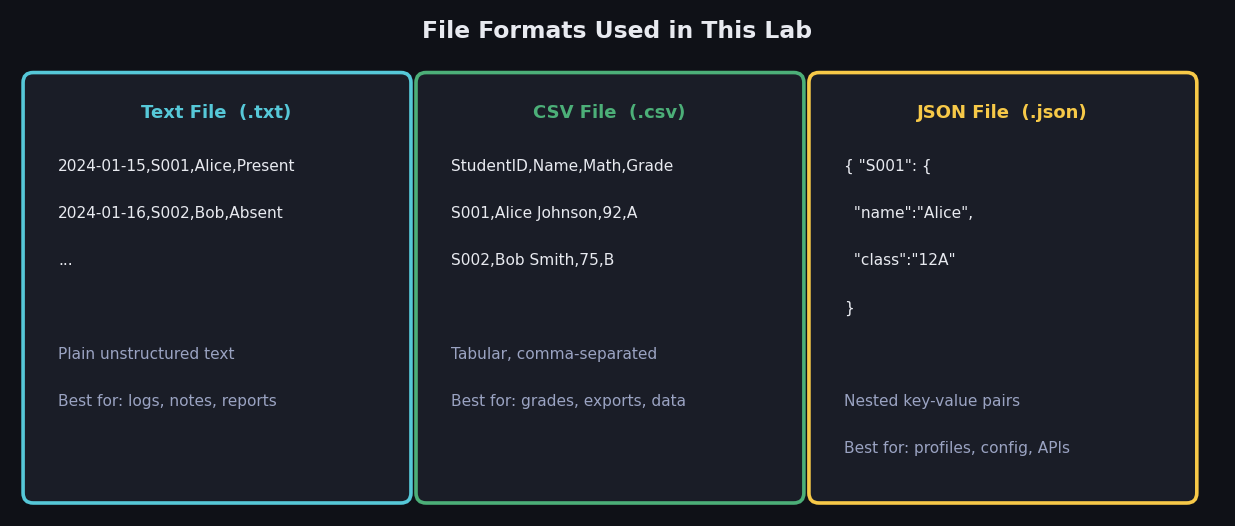


### Explanation of the Diagram

| Format | Structure | When to Use |
|--------|-----------|-------------|
| `.txt` | Unstructured lines | Logs, notes, plain reports |
| `.csv` | Rows and columns | Grades, sales data, exports |
| `.json` | Nested key-value | Profiles, configs, API responses |


In [ ]:
import csv

# ── CSV Files ─────────────────────────────────────────────────────

print("─── csv.reader: rows as lists ─────────────────")
with open("grade_records/grades.csv", "r", newline="") as f:
    reader = csv.reader(f)
    header = next(reader)
    print(f"  Columns : {header}")
    print()
    for row in reader:
        sid, name, math, sci, eng, grade = row
        avg = (int(math) + int(sci) + int(eng)) / 3
        print(f"  {sid}  {name:15s}  Avg: {avg:5.1f}%  Grade: {grade}")

print()
print("─── csv.DictReader: rows as dicts ─────────────")
with open("grade_records/grades.csv", "r", newline="") as f:
    reader = csv.DictReader(f)
    rows = list(reader)

best = max(rows, key=lambda r: int(r["Math"]) + int(r["Science"]) + int(r["English"]))
print(f"  Top student : {best['Name']}")
print(f"  Scores      : Math {best['Math']}  Science {best['Science']}  English {best['English']}")

print()
print("─── csv.DictWriter: add a student, save new CSV ─")
new_student = {"StudentID":"S006","Name":"Frank Lee",
               "Math":"83","Science":"79","English":"88","Grade":"B+"}

with open("grade_records/grades.csv", "r", newline="") as f:
    reader     = csv.DictReader(f)
    fieldnames = reader.fieldnames
    all_rows   = list(reader)

all_rows.append(new_student)

with open("grade_records/grades_updated.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(all_rows)

print(f"  grades_updated.csv written ({len(all_rows)} students):")
with open("grade_records/grades_updated.csv", "r") as f:
    for line in f:
        print("    " + line.rstrip())


**Expected Output:**
```
─── csv.reader: rows as lists ─────────────────
  Columns : ['StudentID', 'Name', 'Math', 'Science', 'English', 'Grade']

  S001  Alice Johnson    Avg:  91.7%  Grade: A
  S002  Bob Smith        Avg:  75.0%  Grade: B
  S003  Carol White      Avg:  88.0%  Grade: A
  S004  David Brown      Avg:  65.7%  Grade: C
  S005  Emma Davis       Avg:  95.0%  Grade: A+

─── csv.DictReader: rows as dicts ─────────────
  Top student : Emma Davis
  Scores      : Math 95  Science 97  English 93

─── csv.DictWriter: add a student, save new CSV ─
  grades_updated.csv written (6 students):
    StudentID,Name,Math,Science,English,Grade
    S001,Alice Johnson,92,88,95,A
    S002,Bob Smith,75,80,70,B
    S003,Carol White,88,91,85,A
    S004,David Brown,60,65,72,C
    S005,Emma Davis,95,97,93,A+
    S006,Frank Lee,83,79,88,B+
```


---

## Section 6: Structured Data — JSON Files

JSON (JavaScript Object Notation) stores nested, flexible data. It is the standard format for APIs, configuration files, and rich records.

| Function | Direction | Description |
|----------|-----------|-------------|
| `json.load(f)` | File → Python | Read and parse a JSON file |
| `json.dump(obj, f)` | Python → File | Serialise to a JSON file |
| `json.loads(s)` | String → Python | Parse a JSON string |
| `json.dumps(obj)` | Python → String | Convert to a JSON string |

**Type mapping:** `dict` ↔ object &nbsp; `list` ↔ array &nbsp; `str` ↔ string &nbsp; `int/float` ↔ number &nbsp; `bool` ↔ true/false &nbsp; `None` ↔ null


In [ ]:
import json, os

# ── JSON Files ────────────────────────────────────────────────────

print("─── json.load(): read a JSON file ─────────────")
with open("grade_records/profiles.json", "r") as f:
    profiles = json.load(f)
print(f"  Type    : {type(profiles).__name__}")
print(f"  Records : {len(profiles)} student profiles\n")
for sid, info in profiles.items():
    print(f"  {sid}: {info['name']:15s} | Class {info['class']} | Age {info['age']}")

print()
print("─── json.dumps(): Python dict -> JSON string ───")
sample = {
    "StudentID": "S001",
    "Name":      "Alice Johnson",
    "scores":    [92, 88, 95],
    "enrolled":  True,
    "guardian":  None,
}
json_str = json.dumps(sample, indent=2)
print(json_str)

print()
print("─── json.loads(): JSON string -> Python dict ───")
parsed = json.loads(json_str)
print(f"  Name        : {parsed['Name']}")
print(f"  Avg score   : {sum(parsed['scores'])/len(parsed['scores']):.1f}")
print(f"  enrolled    : {parsed['enrolled']}  ({type(parsed['enrolled']).__name__})")
print(f"  guardian    : {parsed['guardian']}  ({type(parsed['guardian']).__name__})")

print()
print("─── json.dump(): write updated JSON file ───────")
for sid in profiles:
    profiles[sid]["enrolled"] = True
profiles["S006"] = {"name":"Frank Lee","age":16,"class":"12A",
                    "contact":"frank@school.edu","enrolled":True}
with open("grade_records/profiles_updated.json", "w") as f:
    json.dump(profiles, f, indent=2)
size = os.path.getsize("grade_records/profiles_updated.json")
print(f"  profiles_updated.json saved ({size} bytes, {len(profiles)} profiles)")


**Expected Output:**
```
─── json.load(): read a JSON file ─────────────
  Type    : dict
  Records : 5 student profiles

  S001: Alice Johnson     | Class 12A | Age 17
  S002: Bob Smith         | Class 12A | Age 16
  S003: Carol White       | Class 12B | Age 17
  S004: David Brown       | Class 12B | Age 16
  S005: Emma Davis        | Class 12A | Age 17

─── json.dumps(): Python dict -> JSON string ───
{
  "StudentID": "S001",
  "Name": "Alice Johnson",
  "scores": [92, 88, 95],
  "enrolled": true,
  "guardian": null
}

─── json.loads(): JSON string -> Python dict ───
  Name        : Alice Johnson
  Avg score   : 91.7
  enrolled    : True  (bool)
  guardian    : None  (NoneType)

─── json.dump(): write updated JSON file ───────
  profiles_updated.json saved (XXX bytes, 6 profiles)
```


---

## Section 7: Exception Handling Basics

Without exception handling, any file error crashes the entire program. With it, you control exactly what happens when things go wrong.

```python
try:
    risky_code()          # code that might raise
except SomeError as e:
    handle_it(e)          # what to do if it does
```

**Common file exceptions:**

| Exception | When It Occurs |
|-----------|----------------|
| `FileNotFoundError` | File does not exist |
| `PermissionError` | No read/write permission |
| `IsADirectoryError` | Path points to a folder |
| `ValueError` | File contains unexpected data |
| `UnicodeDecodeError` | File encoding mismatch |


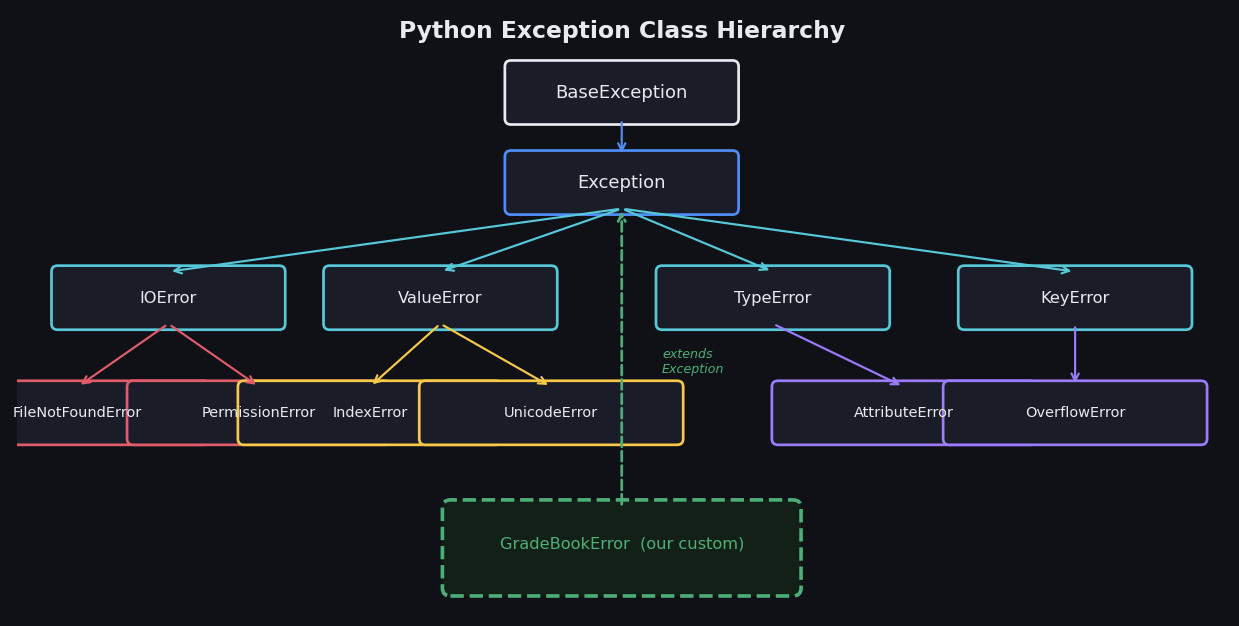


### Explanation of the Diagram

- **`BaseException`** — root of everything (includes `SystemExit`, `KeyboardInterrupt`)
- **`Exception`** — base for all regular, catch-able errors in application code
- `IOError`, `ValueError`, `TypeError` etc. are all subclasses of `Exception`
- `FileNotFoundError` and `PermissionError` are subclasses of `IOError`
- Our custom **`GradeBookError`** (built in Section 9) also extends `Exception`

> **Rule:** Catch the most specific exception type you can. Catching bare `Exception` hides bugs.


In [ ]:
# ── Exception Handling Basics ────────────────────────────────────

print("─── Without handling: program would crash ─────")
print("  open('grade_records/missing.txt')  ->  FileNotFoundError")
print()

print("─── try / except: catch FileNotFoundError ─────")
try:
    with open("grade_records/missing_file.txt", "r") as f:
        data = f.read()
except FileNotFoundError as e:
    print(f"  Caught   : {type(e).__name__}")
    print(f"  Message  : {e}")
    print(f"  Program continues safely.")

print()
print("─── Catching bad data (ValueError) ────────────")
raw_grades = ["92", "88", "N/A", "75", "abc", "91"]
valid, skipped = [], []
for raw in raw_grades:
    try:
        valid.append(int(raw))
    except ValueError:
        skipped.append(raw)
print(f"  Input    : {raw_grades}")
print(f"  Valid    : {valid}")
print(f"  Skipped  : {skipped}")
print(f"  Average  : {sum(valid)/len(valid):.1f}")

print()
print("─── Multiple except clauses ────────────────────")
def safe_lookup(student_id, records):
    """Return average or an error string."""
    try:
        rec = records[student_id]
        return f"{(rec['Math']+rec['Science']+rec['English'])/3:.1f}%"
    except KeyError:
        return f"[KeyError] '{student_id}' not in records"
    except TypeError as e:
        return f"[TypeError] bad data: {e}"

sample = {
    "S001": {"Math":92, "Science":88, "English":95},
    "S003": {"Math":88, "Science":91, "English":85},
}
for sid in ["S001", "S002", "S003"]:
    print(f"  {sid}: {safe_lookup(sid, sample)}")


**Expected Output:**
```
─── Without handling: program would crash ─────
  open('grade_records/missing.txt')  ->  FileNotFoundError

─── try / except: catch FileNotFoundError ─────
  Caught   : FileNotFoundError
  Message  : [Errno 2] No such file or directory: 'grade_records/missing_file.txt'
  Program continues safely.

─── Catching bad data (ValueError) ────────────
  Input    : ['92', '88', 'N/A', '75', 'abc', '91']
  Valid    : [92, 88, 75, 91]
  Skipped  : ['N/A', 'abc']
  Average  : 86.5

─── Multiple except clauses ────────────────────
  S001: 91.7%
  S002: [KeyError] 'S002' not in records
  S003: 88.0%
```


---

## Section 8: Advanced Exception Handling — `else`, `finally`, Re-raising

The full `try` block has four clauses:

```python
try:
    risky_code()
except SomeError:
    handle_error()     # runs ONLY if an exception was raised
else:
    on_success()       # runs ONLY if NO exception was raised
finally:
    cleanup()          # ALWAYS runs — error or not
```

> `finally` is essential for cleanup: close connections, flush buffers, write final log entries.


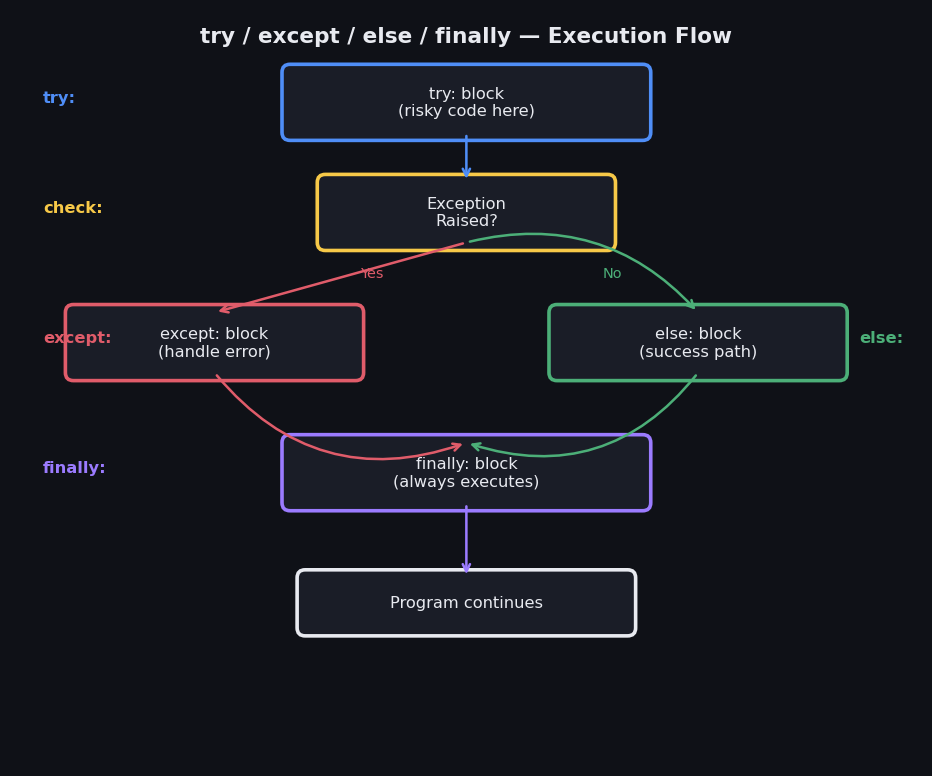


### Explanation of the Diagram

| Block | When It Runs | Typical Purpose |
|-------|-------------|------------------|
| `try` | Always attempted | Put risky code here |
| `except` | Only on exception | Log or recover from the error |
| `else` | Only on success | Process the result |
| `finally` | Always | Close file, release lock, write status |


In [ ]:
# ── Advanced Exception Handling ──────────────────────────────────

print("─── try / except / else / finally ─────────────")
def load_file(filename):
    print(f"\n  Opening: {filename}")
    data = None
    try:
        with open(filename, "r") as f:
            data = f.read()
    except FileNotFoundError:
        print("  [except ] File not found — data stays None.")
    except PermissionError:
        print("  [except ] Permission denied.")
    else:
        print(f"  [else   ] Read OK — {len(data)} characters.")
    finally:
        print("  [finally] Cleanup done — always runs.")
    return data

load_file("grade_records/attendance.txt")   # exists
load_file("grade_records/ghost_file.txt")   # does not exist

print()
print("─── Catching a range of errors at once ─────────")
def parse_score(value):
    try:
        score = float(value)
        if not (0 <= score <= 100):
            raise ValueError(f"Score {score} is outside the range 0-100.")
        return score
    except (ValueError, TypeError) as e:
        print(f"  [error] {e}")
        return None

for v in ["85.5", "110", "-5", "abc", None]:
    result = parse_score(v)
    if result is not None:
        print(f"  parse_score({str(v)!r:6}) = {result}")

print()
print("─── Re-raising: log then let caller handle ─────")
def strict_load(filename):
    try:
        with open(filename, "r") as f:
            return f.read()
    except FileNotFoundError as e:
        print(f"  [log] Missing file: {filename}")
        raise              # re-raise the original exception

try:
    strict_load("grade_records/no_such_file.txt")
except FileNotFoundError:
    print("  [caller] Handled the re-raised FileNotFoundError.")


**Expected Output:**
```
─── try / except / else / finally ─────────────

  Opening: grade_records/attendance.txt
  [else   ] Read OK — XXX characters.
  [finally] Cleanup done — always runs.

  Opening: grade_records/ghost_file.txt
  [except ] File not found — data stays None.
  [finally] Cleanup done — always runs.

─── Catching a range of errors at once ─────────
  [error] Score 110.0 is outside the range 0-100.
  [error] Score -5.0 is outside the range 0-100.
  [error] could not convert string to float: 'abc'
  [error] float() argument must be a string or a number, not 'NoneType'
  parse_score('85.5') = 85.5

─── Re-raising: log then let caller handle ─────
  [log] Missing file: grade_records/no_such_file.txt
  [caller] Handled the re-raised FileNotFoundError.
```


---

## Section 9: Custom Exceptions

Built-in exceptions are generic. Custom exceptions make error messages precise and let callers catch domain-specific problems independently.

```python
class AppError(Exception):
    pass

class SpecificError(AppError):
    def __init__(self, detail):
        super().__init__(f'Specific problem: {detail}')
```

**Why define custom exceptions?**
- Self-documenting: `except StudentNotFoundError` explains itself
- Granular: callers catch exactly what they can handle
- Rich info: attach extra attributes like `.student_id` or `.filename`


In [ ]:
import json

# ── Custom Exception Hierarchy ────────────────────────────────────

class GradeBookError(Exception):
    """Base class for all SmartGrade errors."""
    pass

class StudentNotFoundError(GradeBookError):
    """Raised when a student ID is not in the records."""
    def __init__(self, student_id):
        self.student_id = student_id
        super().__init__(f"Student '{student_id}' not found in records.")

class GradeOutOfRangeError(GradeBookError):
    """Raised when a grade falls outside the valid range 0-100."""
    def __init__(self, subject, value):
        self.subject = subject
        self.value   = value
        super().__init__(f"Grade {value} for '{subject}' is outside valid range 0-100.")

class CorruptFileError(GradeBookError):
    """Raised when a file contains malformed data."""
    def __init__(self, filename, detail=""):
        super().__init__(f"Corrupt data in '{filename}'. {detail}")

# ── Demonstrating custom exceptions ──────────────────────────────

print("─── StudentNotFoundError ───────────────────────")
with open("grade_records/profiles.json", "r") as f:
    profiles = json.load(f)

def get_profile(student_id):
    if student_id not in profiles:
        raise StudentNotFoundError(student_id)
    return profiles[student_id]

for sid in ["S001", "S003", "S999"]:
    try:
        info = get_profile(sid)
        print(f"  Found  : {info['name']:15s} (class {info['class']})")
    except StudentNotFoundError as e:
        print(f"  Error  : {e}")
        print(f"  Bad ID : {e.student_id}")

print()
print("─── GradeOutOfRangeError ───────────────────────")
def validate_grade(subject, value):
    if not (0 <= value <= 100):
        raise GradeOutOfRangeError(subject, value)
    return value

for subject, grade in [("Math",92), ("Science",110), ("English",-5), ("Math",0)]:
    try:
        v = validate_grade(subject, grade)
        print(f"  {subject:10s}: {v:5.1f}  valid")
    except GradeOutOfRangeError as e:
        print(f"  {subject:10s}: {e}")

print()
print("─── isinstance check across the hierarchy ──────")
err = GradeOutOfRangeError("Math", 110)
print(f"  Is GradeOutOfRangeError?  {isinstance(err, GradeOutOfRangeError)}")
print(f"  Is GradeBookError?        {isinstance(err, GradeBookError)}")
print(f"  Is Exception?             {isinstance(err, Exception)}")
print(f"  Is StudentNotFoundError?  {isinstance(err, StudentNotFoundError)}")


**Expected Output:**
```
─── StudentNotFoundError ───────────────────────
  Found  : Alice Johnson    (class 12A)
  Found  : Carol White      (class 12B)
  Error  : Student 'S999' not found in records.
  Bad ID : S999

─── GradeOutOfRangeError ───────────────────────
  Math      :  92.0  valid
  Science   : Grade 110 for 'Science' is outside valid range 0-100.
  English   : Grade -5 for 'English' is outside valid range 0-100.
  Math      :   0.0  valid

─── isinstance check across the hierarchy ──────
  Is GradeOutOfRangeError?  True
  Is GradeBookError?        True
  Is Exception?             True
  Is StudentNotFoundError?  False
```


---

## Final Project: SmartGrade GradeBook

Every skill from this lab combines into one production-quality `GradeBook` class.

| Skill | Where It Appears |
|-------|------------------|
| `open()` + modes | Every file method |
| `read()` / `write()` / `writelines()` | Loading and report generation |
| `with` context manager | All I/O in every method |
| `csv` module | `load_csv()`, `save_csv()` |
| `json` module | `load_profiles()` |
| `try/except/else/finally` | Every method guards its file I/O |
| Custom exceptions | `StudentNotFoundError`, `GradeOutOfRangeError`, `CorruptFileError` |
| Append mode | Persistent audit log (`gradebook.log`) |

### Part A — Class Definitions


In [ ]:
import csv, json, os
from datetime import datetime

# ── Custom exceptions ──────────────────────────────────────────────
class GradeBookError(Exception):
    pass

class StudentNotFoundError(GradeBookError):
    def __init__(self, student_id):
        self.student_id = student_id
        super().__init__(f"Student '{student_id}' not found.")

class GradeOutOfRangeError(GradeBookError):
    def __init__(self, subject, value):
        super().__init__(f"Grade {value} for '{subject}' is outside valid range 0-100.")

class CorruptFileError(GradeBookError):
    def __init__(self, filename, detail=""):
        super().__init__(f"Corrupt data in '{filename}'. {detail}")

# ── GradeBook class ────────────────────────────────────────────────
class GradeBook:
    """
    Student grade management system.
    Reads CSV and JSON; writes text reports, CSV exports, and an audit log.
    All file I/O is wrapped in exception handling.
    """
    SUBJECTS = ["Math", "Science", "English"]
    LOG_FILE = "grade_records/gradebook.log"

    def __init__(self, name):
        self.name      = name
        self._students = {}
        os.makedirs("grade_records", exist_ok=True)
        self._log(f"GradeBook '{name}' initialized.")

    # ── Append one entry to the audit log ─────────────────────────
    def _log(self, message):
        ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        with open(self.LOG_FILE, "a") as f:
            f.write(f"[{ts}] {message}\n")

    # ── Load grades from a CSV file ───────────────────────────────
    def load_csv(self, filepath):
        try:
            with open(filepath, "r", newline="") as f:
                reader = csv.DictReader(f)
                count  = 0
                for row in reader:
                    sid = row["StudentID"]
                    try:
                        grades = {s: int(row[s]) for s in self.SUBJECTS}
                    except (KeyError, ValueError) as e:
                        raise CorruptFileError(filepath, str(e)) from e
                    self._students[sid] = {
                        "name":   row["Name"],
                        "class":  "Unknown",
                        "grades": grades,
                    }
                    count += 1
            self._log(f"Loaded {count} students from {filepath}.")
            return count
        except FileNotFoundError:
            self._log(f"ERROR: CSV not found — {filepath}")
            raise

    # ── Merge profile data from a JSON file ───────────────────────
    def load_profiles(self, filepath):
        try:
            with open(filepath, "r") as f:
                profiles = json.load(f)
            merged = 0
            for sid, info in profiles.items():
                if sid in self._students:
                    self._students[sid]["class"]   = info.get("class",   "?")
                    self._students[sid]["contact"] = info.get("contact", "")
                    merged += 1
            self._log(f"Profiles merged ({merged} matched) from {filepath}.")
        except FileNotFoundError:
            self._log(f"WARNING: Profiles missing — {filepath}. Skipping.")
        except json.JSONDecodeError as e:
            self._log(f"ERROR: Invalid JSON in {filepath} — {e}")
            raise

    # ── Retrieve one student (raises if absent) ───────────────────
    def get_student(self, student_id):
        if student_id not in self._students:
            raise StudentNotFoundError(student_id)
        return self._students[student_id]

    # ── Update a single grade ─────────────────────────────────────
    def update_grade(self, student_id, subject, value):
        student = self.get_student(student_id)
        if subject not in self.SUBJECTS:
            raise ValueError(f"Subject '{subject}' not recognised. Valid: {self.SUBJECTS}")
        if not (0 <= value <= 100):
            raise GradeOutOfRangeError(subject, value)
        student["grades"][subject] = value
        self._log(f"Updated {student_id} {subject} -> {value}.")

    # ── Calculate average for one student ─────────────────────────
    def average(self, student_id):
        g = self.get_student(student_id)["grades"]
        return sum(g.values()) / len(g)

    # ── Save a formatted text report ──────────────────────────────
    def save_report(self, filepath):
        try:
            sep = "=" * 56
            with open(filepath, "w") as f:
                f.write(f"{sep}\n")
                f.write(f"  {self.name.upper()} — GRADE REPORT\n")
                f.write(f"  Generated : {datetime.now():%Y-%m-%d %H:%M}\n")
                f.write(f"{sep}\n\n")
                f.write(f"  {'ID':5} {'Name':16} {'Math':>5} {'Sci':>5}"
                        f" {'Eng':>5} {'Avg':>6} {'Grade':>5}\n")
                f.write(f"  {'-' * 54}\n")
                for sid, s in sorted(self._students.items()):
                    g   = s["grades"]
                    avg = sum(g.values()) / len(g)
                    ltr = ("A+" if avg>=95 else "A" if avg>=90 else
                           "B+" if avg>=85 else "B" if avg>=75 else "C")
                    f.write(f"  {sid:5} {s['name']:16} {g['Math']:>5}"
                            f" {g['Science']:>5} {g['English']:>5}"
                            f" {avg:>6.1f} {ltr:>5}\n")
                class_avg = (sum(self.average(s) for s in self._students)
                             / len(self._students))
                f.write(f"\n  Total students : {len(self._students)}\n")
                f.write(f"  Class average  : {class_avg:.1f}%\n")
                f.write(f"{sep}\n")
            self._log(f"Report saved -> {filepath}.")
        except IOError as e:
            self._log(f"ERROR: Cannot write report — {e}")
            raise

    # ── Save updated data as CSV ───────────────────────────────────
    def save_csv(self, filepath):
        fields = ["StudentID","Name","Class","Math","Science","English","Average","Grade"]
        with open(filepath, "w", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=fields)
            writer.writeheader()
            for sid, s in self._students.items():
                avg = self.average(sid)
                ltr = ("A+" if avg>=95 else "A" if avg>=90 else
                       "B+" if avg>=85 else "B" if avg>=75 else "C")
                writer.writerow({
                    "StudentID": sid, "Name": s["name"], "Class": s["class"],
                    "Math": s["grades"]["Math"], "Science": s["grades"]["Science"],
                    "English": s["grades"]["English"],
                    "Average": f"{avg:.1f}", "Grade": ltr,
                })
        self._log(f"CSV saved -> {filepath}.")

    def __str__(self):
        return f"GradeBook('{self.name}', {len(self._students)} students)"

    def __repr__(self):
        return self.__str__()


print("Classes defined:")
print("  GradeBookError, StudentNotFoundError,")
print("  GradeOutOfRangeError, CorruptFileError")
print("  GradeBook")


### Part B — Running SmartGrade for a Day


In [ ]:
# ══════════════════════════════════════════════════════════════
#  FINAL PROJECT — Part B: Running the SmartGrade System
# ══════════════════════════════════════════════════════════════

# ── Step 1: Initialise and load data ──────────────────────────
print("─── Step 1: Initialise & Load Data ─────────────────────")
gb = GradeBook("City High School — Term 1")
n  = gb.load_csv("grade_records/grades.csv")
print(f"  Loaded {n} students from CSV.")
gb.load_profiles("grade_records/profiles.json")
print(f"  Profiles merged.")
print(f"  {gb}")

# ── Step 2: View student records ──────────────────────────────
print()
print("─── Step 2: View Student Records ───────────────────────")
for sid in ["S001", "S003", "S005"]:
    s   = gb.get_student(sid)
    avg = gb.average(sid)
    print(f"  {sid}: {s['name']:15s} | Class {s['class']} | Avg: {avg:.1f}%")

# ── Step 3: Update grades with full exception handling ────────
print()
print("─── Step 3: Update Grades (with validation) ─────────────")
gb.update_grade("S002", "Math", 82)
print("  Updated S002 Math: 75 -> 82")

test_updates = [
    ("S999", "Math",      90),
    ("S001", "Math",     110),
    ("S001", "Chemistry", 88),
]
for sid, subj, val in test_updates:
    try:
        gb.update_grade(sid, subj, val)
    except StudentNotFoundError as e:
        print(f"  StudentNotFoundError : {e}")
    except GradeOutOfRangeError as e:
        print(f"  GradeOutOfRangeError : {e}")
    except ValueError as e:
        print(f"  ValueError           : {e}")

# ── Step 4: Save files ────────────────────────────────────────
print()
print("─── Step 4: Save Report & CSV ───────────────────────────")
gb.save_report("grade_records/final_report.txt")
gb.save_csv("grade_records/final_grades.csv")
print("  Saved: grade_records/final_report.txt")
print("  Saved: grade_records/final_grades.csv")

# ── Step 5: Display the report ────────────────────────────────
print()
print("─── Step 5: Generated Report ────────────────────────────")
with open("grade_records/final_report.txt", "r") as f:
    print(f.read())

# ── Step 6: Display the audit log ────────────────────────────
print("─── Step 6: Audit Log (gradebook.log) ───────────────────")
with open("grade_records/gradebook.log", "r") as f:
    for line in f:
        print(" ", line.rstrip())

# ── Step 7: List every file created ──────────────────────────
print()
print("─── Step 7: All Files in grade_records/ ─────────────────")
for fname in sorted(os.listdir("grade_records")):
    size = os.path.getsize(f"grade_records/{fname}")
    print(f"  {fname:32s} {size:5d} bytes")


**Expected Output:**
```
─── Step 1: Initialise & Load Data ─────────────────────
  Loaded 5 students from CSV.
  Profiles merged.
  GradeBook('City High School — Term 1', 5 students)

─── Step 2: View Student Records ───────────────────────
  S001: Alice Johnson     | Class 12A | Avg: 91.7%
  S003: Carol White       | Class 12B | Avg: 88.0%
  S005: Emma Davis        | Class 12A | Avg: 95.0%

─── Step 3: Update Grades (with validation) ─────────────
  Updated S002 Math: 75 -> 82
  StudentNotFoundError : Student 'S999' not found.
  GradeOutOfRangeError : Grade 110 for 'Math' is outside valid range 0-100.
  ValueError           : Subject 'Chemistry' not recognised. Valid: ['Math', 'Science', 'English']

─── Step 4: Save Report & CSV ───────────────────────────
  Saved: grade_records/final_report.txt
  Saved: grade_records/final_grades.csv

─── Step 5: Generated Report ────────────────────────────
========================================================
  CITY HIGH SCHOOL — TERM 1 — GRADE REPORT
  Generated : YYYY-MM-DD HH:MM
========================================================

  ID    Name              Math   Sci   Eng    Avg Grade
  ------------------------------------------------------
  S001  Alice Johnson       92    88    95   91.7     A
  S002  Bob Smith           82    80    70   77.3     B
  S003  Carol White         88    91    85   88.0    B+
  S004  David Brown         60    65    72   65.7     C
  S005  Emma Davis          95    97    93   95.0    A+

  Total students : 5
  Class average  : 83.5%
========================================================

─── Step 6: Audit Log (gradebook.log) ───────────────────
  [YYYY-MM-DD HH:MM:SS] GradeBook 'City High School — Term 1' initialized.
  [YYYY-MM-DD HH:MM:SS] Loaded 5 students from grade_records/grades.csv.
  [YYYY-MM-DD HH:MM:SS] Profiles merged (5 matched) from grade_records/profiles.json.
  [YYYY-MM-DD HH:MM:SS] Updated S002 Math -> 82.
  [YYYY-MM-DD HH:MM:SS] Report saved -> grade_records/final_report.txt.
  [YYYY-MM-DD HH:MM:SS] CSV saved -> grade_records/final_grades.csv.

─── Step 7: All Files in grade_records/ ─────────────────
  attendance.txt                    XXX bytes
  final_grades.csv                  XXX bytes
  final_report.txt                  XXX bytes
  gradebook.log                     XXX bytes
  grades.csv                        XXX bytes
  grades_updated.csv                XXX bytes
  profiles.json                     XXX bytes
  profiles_updated.json             XXX bytes
  report.txt                        XXX bytes
  subjects.txt                       56 bytes
```


---

## What We Built and How Every Skill Contributed

| Skill | Used In |
|-------|---------|
| `open()` + file modes | All file operations throughout the lab |
| `read()`, `readlines()` | Section 2 — four ways to read the attendance log |
| `write()`, `writelines()` | Section 3 — grade report and new records |
| `with` context manager | Section 4 onward — every single file operation |
| `csv.reader` / `DictReader` | Section 5 — `GradeBook.load_csv()`, reporting |
| `json.load()` / `json.dump()` | Section 6 — `GradeBook.load_profiles()` |
| `try / except` | Section 7 — all I/O wrapped safely |
| `else / finally` | Section 8 — audit logging and cleanup |
| Custom exceptions | Section 9 — `StudentNotFoundError`, `GradeOutOfRangeError` |
| Append mode `"a"` | GradeBook `_log()` — persistent audit trail |

---

### Key Takeaways

1. **Always use `with`** — never leave files open manually.
2. **Catch specific exceptions** — prefer `FileNotFoundError` over bare `except`.
3. **Use `finally` for cleanup** — it runs even when exceptions occur.
4. **Custom exceptions** make code self-documenting and far easier to debug.
5. **CSV** for tabular data, **JSON** for nested structures, **text** for logs and reports.
